In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
from ast import literal_eval
from collections import defaultdict
import pickle
import random
from pyvis.network import Network
import networkx as nx
from captum.attr import IntegratedGradients


from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import init
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [2]:

# Define the directory path
directory_path = '../data/raw/'

# Load data
sms_data = pd.read_csv(f'{directory_path}train/train_sms.csv')
voc_data = pd.read_csv(f'{directory_path}train/train_voc.csv')
dataset = pd.read_csv('../data/processed/processed_dataset.csv')

/var/folders/rh/zzd0r4d138qcmkk4wydl6k600000gn/T/ipykernel_22282/3612316307.py:6: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  voc_data = pd.read_csv(f'{directory_path}train/train_voc.csv')


In [ ]:
# Logistic Regression to know what columns are important
# 2. Drop irrelevant columns
irrelevant_cols = [
    'imei_list', 'phone_no_m',
    "voc_hour_mode", 'voc_day_mode', 'sms_hour_mode', 'sms_day_mode', 'voc_dayname_mode_count', 'sms_dayname_mode_count',
    'flow_sum', 'call_county_unique', 'voc_hour_mode_count', 'sms_day_mode_count'
]
df_log = dataset.drop(columns=irrelevant_cols)

# 3. Fill NaN with 0
df_log = df_log.fillna(0)

# 4. Separate features and labels
X = df_log.drop(columns=["label"])
y = df_log["label"]

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4211, stratify=y)

# 6. Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Logistic Regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)


# 8. Feature importance
feature_names = X.columns
coefs = model.coef_[0]

coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
coeff_df['AbsCoefficient'] = coeff_df['Coefficient'].abs()
important_features = coeff_df[coeff_df['AbsCoefficient'] > 0.25]['Feature'].tolist()

# 9. Create node_features from full dataset
columns_to_keep = important_features + ['phone_no_m', 'label','imei_list']
print(columns_to_keep)

['arpu_mean', 'arpu_max', 'arpu_min', 'arpu_median', 'idcard_cnt', 'months_count', 'imei_count', 'call_count', 'call_unique', 'call_count_median', 'call_dur_mean', 'voc_hour_unique', 'voc_day_mode_count', 'voc_date_unique', 'voc_dayname_unique', 'voc_calltype1_count', 'voc_calltype2_count', 'call_duration_per_contact_mean', 'sms_nunique_contact', 'sms_date_nunique', 'sms_hour_mode_count', 'sms_hour_nunique', 'sms_rate', 'sms_contacts_proportion', 'sms_calltype1_count', 'sms_calltype2_proportion', 'phone_no_m', 'label', 'imei_list']


/Users/britneysaw/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
df = dataset.copy()
# drop irrelevant predictors
df.drop(columns=[ "voc_hour_mode",'voc_day_mode','sms_hour_mode','sms_day_mode', 'voc_dayname_mode_count', 'sms_dayname_mode_count', 'flow_sum', 'call_county_unique', 'voc_hour_mode_count', 'sms_day_mode_count'], inplace=True)

# Fill NaN values with 0
df = df.fillna(0)
df = df[columns_to_keep]

# Extract labels and features
labels = df[['phone_no_m', 'label']]
features = df.drop(columns=['label']) 


# Identify numerical and categorical features
numerical_features = features.columns.difference(['phone_no_m', 'imei_list'])

# Standardize numerical features
standard_scaler = StandardScaler()
features[numerical_features] = standard_scaler.fit_transform(features[numerical_features].fillna(features[numerical_features].mean()))


# Create node features matrix
node_features = features[numerical_features].values
node_ids = features['phone_no_m'].values
num_nodes = len(node_ids)

# Create mapping from phone number to node index
phone_to_index = {phone: idx for idx, phone in enumerate(node_ids)}

# Create labels array (aligned with node indices)
labels_array = labels.set_index('phone_no_m')['label'].reindex(node_ids).values

In [5]:
#################################### Create Relation 1: Similarity Graph ####################################

# Compute similarity graph (cosine similarity)
similarity_matrix = cosine_similarity(features[numerical_features])
similarity_df = pd.DataFrame(similarity_matrix, index=df["phone_no_m"], columns=df["phone_no_m"])

# Map phone numbers to indices for quick lookup
phone_to_index = {phone: idx for idx, phone in enumerate(node_ids)}

k_nearest_neighbours = 15 ## change to 10,15,20,50

# Initialize relation graph (adjacency matrix)
adj_matrix1 = np.zeros((num_nodes, num_nodes))

for i, phone1 in enumerate(df["phone_no_m"]):
    # Step 0: Get all similarities (excluding self)
    similarities = [
        (j, similarity_matrix[i, j])
        for j in range(len(df["phone_no_m"])) if i != j
    ]
    
    positive = sorted([p for p in similarities], key=lambda x: x[1], reverse=True)

    # Select neighbors based strictly on k-nearest neighbours
    selected = []
    selected += positive[:k_nearest_neighbours+1]

    # Update adjacency matrix
    for neighbor_idx, sim in selected:
        neighbor = df["phone_no_m"].iloc[neighbor_idx]
        j = phone_to_index[neighbor]
        adj_matrix1[i, j] = sim
        adj_matrix1[j, i] = sim  # Symmetric matrix

# Remove self-loops
np.fill_diagonal(adj_matrix1, 0) 

# Convert adjacency matrix to sparse matrix
adj_matrix1_sparse = sp.csr_matrix(adj_matrix1)

In [ ]:
#################################### relation 2 (calls and sms) #######################################

combined_data = pd.concat([voc_data[["phone_no_m", "opposite_no_m"]], sms_data[["phone_no_m", "opposite_no_m"]]])

# Group by 'phone_no_m' and create a set of unique 'opposite_no_m' values
grouped_data = combined_data.groupby("phone_no_m")["opposite_no_m"].apply(set).reset_index()

# Create a dictionary for quick lookup of opposite_no_m sets
opposite_dict = dict(zip(grouped_data["phone_no_m"], grouped_data["opposite_no_m"]))

# Find phone_no_m values that:
# (1) Appear in another phone_no_m's opposite_no_m list
# (2) Share common opposite_no_m contacts
def find_phone_in_opposite(phone, opposite_dict):
    linked_phones = set()
    
    for other_phone, opposite_set in opposite_dict.items():
        if phone == other_phone:
            continue  # Skip itself
        
        # Condition 1: phone appears in another's opposite list
        if phone in opposite_set:
            linked_phones.add(other_phone)

    return list(linked_phones)

# Apply the function to each phone_no_m
grouped_data["phone_in_opposite"] = grouped_data["phone_no_m"].apply(lambda phone: find_phone_in_opposite(phone, opposite_dict))
adj_matrix2 = np.zeros((num_nodes, num_nodes), dtype=int)

# Convert grouped_data into a dictionary
phone_graph = dict(zip(grouped_data["phone_no_m"], grouped_data["phone_in_opposite"]))

# Build adjacency matrix using phone mappings
for phone, connected_phones in phone_graph.items():
    if phone not in phone_to_index:
        continue
    u = phone_to_index[phone]  # Convert phone_no_m to index
    for other_phone in connected_phones:
        if other_phone in phone_to_index:
            v = phone_to_index[other_phone]
            adj_matrix2[u, v] = 1
            adj_matrix2[v, u] = 1  # Undirected graph

# Convert to sparse matrix
adj_matrix2_sparse = sp.csr_matrix(adj_matrix2)

In [ ]:
# Create inverse mapping from index to phone number
index_to_phone = {v: k for k, v in phone_to_index.items()}

# Get all nodes that have at least one connection
connected_nodes = [
    phone for phone in grouped_data["phone_no_m"] 
    if phone in phone_to_index and 
    adj_matrix2_sparse[phone_to_index[phone]].getnnz() > 0
]
# Create a dictionary for labels
label_dict = {phone: {"label": labels_array[phone_to_index[phone]]} for phone in connected_nodes}

# Select subset of connected nodes to display
num_nodes_to_display = 600 
nodes_to_display = connected_nodes[:num_nodes_to_display]

# Filter nodes to only those with connections WITHIN the subset
candidate_set = set(nodes_to_display)
filtered_nodes = []

for phone in nodes_to_display:
    u = phone_to_index[phone]
    neighbors_indices = adj_matrix2_sparse[u].indices
    neighbor_phones = [index_to_phone[v] for v in neighbors_indices if v in index_to_phone]
    
    # Keep only if has at least one neighbor in the display subset
    if any(np in candidate_set for np in neighbor_phones):
        filtered_nodes.append(phone)

nodes_to_display = filtered_nodes

# Initialize network
net = Network(
    notebook=True, 
    height="750px", 
    width="100%", 
    bgcolor="white", 
    font_color="black", 
    directed=False
)

# Add only filtered nodes with connections
for phone in nodes_to_display:
    node_color = "#808080"
    if phone in label_dict:
        label_value = label_dict[phone].get('label', -1)
        node_color = "salmon" if label_value == 0 else "skyblue"
    net.add_node(phone, color=node_color, label=" ")

# Add edges between filtered nodes
added_edges = set()

for phone1 in nodes_to_display:
    u = phone_to_index[phone1]
    neighbors_indices = adj_matrix2_sparse[u].indices
    
    for v in neighbors_indices:
        phone2 = index_to_phone.get(v)
        if phone2 and phone2 in nodes_to_display and phone1 != phone2:
            edge_pair = tuple(sorted([phone1, phone2]))
            
            if edge_pair not in added_edges:
                net.add_edge(
                    phone1, 
                    phone2, 
                    title="Connected via calls/SMS", 
                    color="#cccccc",
                    width = 3
                )
                added_edges.add(edge_pair)

# Remove any nodes that ended up with no connections
nodes_to_remove = [
    node["id"] for node in net.nodes 
    if len(net.get_adj_list()[node["id"]]) == 0
]

for node_id in nodes_to_remove:
    net.nodes.remove(next(n for n in net.nodes if n["id"] == node_id))

# Configure physics for better visualization
net.set_options("""
{
    "physics": {
        "forceAtlas2Based": {
            "gravitationalConstant": -100,
            "centralGravity": 0.01,
            "springLength": 200,
            "springConstant": 0.08
        },
        "minVelocity": 0.75,
        "solver": "forceAtlas2Based"
    }
}
""")

# Save visualization
net.save_graph("call_sms_subgraph.html")

In [7]:
#################################### Create Relation 3: Shared IMEI Graph (as sparse matrix) ####################################

df_cleaned = dataset[["phone_no_m", "imei_list"]].dropna(subset=['imei_list']) # changed this to use dataset to drop it from df
df_cleaned["imei_list"] = df_cleaned["imei_list"].fillna("")
df_cleaned["imei_list"] = df_cleaned["imei_list"].apply(
    lambda x: literal_eval(x) if isinstance(x, str) else x
)
df_exploded = df_cleaned.explode('imei_list')

# Group by IMEI and create edges
imei_groups = df_exploded.groupby('imei_list')['phone_no_m'].apply(list)
adj_matrix3 = np.zeros((num_nodes, num_nodes), dtype=int)
for phones in imei_groups:
    phone_indices = [phone_to_index[phone] for phone in phones if phone in phone_to_index]
    for i in range(len(phone_indices)):
        for j in range(i+1, len(phone_indices)):
            u, v = phone_indices[i], phone_indices[j]
            adj_matrix3[u, v] += 1
            adj_matrix3[v, u] += 1

adj_matrix3 = (adj_matrix3 > 0).astype(int)
adj_matrix3_sparse = sp.csr_matrix(adj_matrix3)

In [ ]:
g = nx.Graph()

# Create a reverse mapping from index to phone number
index_to_phone = {v: k for k, v in phone_to_index.items()}

# Add all nodes to the graph
for phone in phone_to_index.keys():
    g.add_node(phone)

# Add edges from the sparse matrix
rows, cols = adj_matrix3_sparse.nonzero()
for i, j in zip(rows, cols):
    if i < j:  # Only add each edge once (since the matrix is symmetric)
        phone1 = index_to_phone[i]
        phone2 = index_to_phone[j]
        
        # Count shared IMEIs by checking which IMEIs both phones have
        phone1_imeis = set(df_exploded[df_exploded['phone_no_m'] == phone1]['imei_list'])
        phone2_imeis = set(df_exploded[df_exploded['phone_no_m'] == phone2]['imei_list'])
        shared_imeis = phone1_imeis.intersection(phone2_imeis)
        
        g.add_edge(phone1, phone2, imei_count=len(shared_imeis))

# Add fraud labels to nodes using labels_array
for phone, idx in phone_to_index.items():
    if idx < len(labels_array):
        g.nodes[phone]['fraud_label'] = int(labels_array[idx])

# Find connected components
connected_components = list(nx.connected_components(g))
print(f"Number of connected components: {len(connected_components)}")

# Sort components by size (largest first)
connected_components.sort(key=len, reverse=True)

# Print component statistics
component_sizes = [len(component) for component in connected_components]
print(f"Largest component size: {max(component_sizes)}")
print(f"Second largest component size: {component_sizes[1] if len(component_sizes) > 1 else 0}")
print(f"Smallest component size: {min(component_sizes)}")

# Skip the largest component
components_to_analyze = connected_components[1:]  # Skip index 0 (largest component)

# Classify components by fraud status
fraud_components = []
non_fraud_components = []
mixed_components = []

for i, component in enumerate(components_to_analyze, start=1):  # Start index at 1 since we skipped 0
    # Count fraud and non-fraud nodes in this component
    fraud_count = sum(1 for node in component if g.nodes[node]['fraud_label'] == 1)
    non_fraud_count = sum(1 for node in component if g.nodes[node]['fraud_label'] == 0)
    
    # Classify the component
    if fraud_count > 0 and non_fraud_count == 0:
        fraud_components.append((i, component, len(component)))
    elif non_fraud_count > 0 and fraud_count == 0:
        non_fraud_components.append((i, component, len(component)))
    elif fraud_count > 0 and non_fraud_count > 0:
        mixed_components.append((i, component, len(component)))

print(f"Found {len(fraud_components)} fraud-only components")
print(f"Found {len(non_fraud_components)} non-fraud-only components")
print(f"Found {len(mixed_components)} mixed components")

# Select components to visualize
components_to_show = []

# Add some of each type of component
for comp_list, max_count in [
    (fraud_components, 5), 
    (mixed_components, 5), 
    (non_fraud_components, 5)
]:
    # Sort by size (largest first)
    sorted_comps = sorted(comp_list, key=lambda x: x[2], reverse=True)
    for i, (idx, component, size) in enumerate(sorted_comps):
        if i < max_count:
            components_to_show.append((idx, component))

# Create a subgraph with only the selected components. Excluded the largest connected component.
nodes_to_display = []
for _, component in components_to_show:
    nodes_to_display.extend(component)

subgraph = g.subgraph(nodes_to_display)

# Find isolated nodes (nodes with degree 0)
isolated_nodes = [node for node in g.nodes() if g.degree(node) == 0]

# Sample some isolated nodes to include
max_isolated_to_show = 50
isolated_fraud = [node for node in isolated_nodes if g.nodes[node].get('fraud_label', 0) == 1][:max_isolated_to_show//2]
isolated_non_fraud = [node for node in isolated_nodes if g.nodes[node].get('fraud_label', 0) == 0][:max_isolated_to_show//2]
isolated_to_show = isolated_fraud + isolated_non_fraud

# Create PyVis network
net = Network(
    height="750px", 
    width="100%", 
    bgcolor="#ffffff", 
    font_color="black",
    directed=False,
    notebook=True
)

# Add connected component nodes to the network
for node in subgraph.nodes():
    fraud_label = subgraph.nodes[node].get('fraud_label', 0)
    color = "salmon" if fraud_label == 1 else "skyblue"
    
    # Find which component this node belongs to
    for comp_idx, component in components_to_show:
        if node in component:
            component_id = comp_idx
            break
    
    net.add_node(
        node, 
        color=color, 
        title=f"Phone: {node}, Fraud: {fraud_label}, Component: {component_id}",
        size=22,
        label=""
    )

# Add isolated nodes to the network
for i, node in enumerate(isolated_to_show):
    fraud_label = g.nodes[node].get('fraud_label', 0)
    color = "salmon" if fraud_label == 1 else "skyblue"
    
    net.add_node(
        f"isolated_{i}_{node}", # Add prefix to avoid ID conflicts
        color=color, 
        title=f"Isolated Phone: {node}, Fraud: {fraud_label}",
        size=22,
        label=""
    )

# Add edges to the network
for source, target, data in subgraph.edges(data=True):
    # Color edges based on the nodes they connect
    source_fraud = subgraph.nodes[source].get('fraud_label', 0)
    target_fraud = subgraph.nodes[target].get('fraud_label', 0)
    
    if source_fraud == 1 and target_fraud == 1:
        edge_color = "#ffcccc"  # Light red for fraud-fraud
    elif source_fraud == 0 and target_fraud == 0:
        edge_color = "#cce5ff"  # Light blue for non-fraud-non-fraud
    else:
        edge_color = "#e6e6e6"  # Light gray for mixed
    
    net.add_edge(
        source, 
        target, 
        title=f"Shared IMEIs: {data.get('imei_count', 1)}", 
        color=edge_color,
        width=1 + min(data.get('imei_count', 1), 5)  # Edge width based on number of shared IMEIs
    )

# Configure physics for better visualization
net.set_options("""
{
    "physics": {
        "forceAtlas2Based": {
            "gravitationalConstant": -100,
            "centralGravity": 0.01,
            "springLength": 150,
            "springConstant": 0.05,
            "avoidOverlap": 0.8
        },
        "minVelocity": 0.75,
        "solver": "forceAtlas2Based",
        "stabilization": {
            "enabled": true,
            "iterations": 1000
        }
    },
    "layout": {
        "improvedLayout": true
    }
}
""")

# Save visualization
net.save_graph("shared_imei_subgraph.html")

Number of connected components: 5442
Largest component size: 335
Second largest component size: 42
Smallest component size: 1
Found 1312 fraud-only components
Found 4123 non-fraud-only components
Found 6 mixed components


In [75]:
# Save adjacency lists
def sparse_to_adjlist(sp_matrix, filename):
    adj_lists = defaultdict(set)
    edges = sp_matrix.nonzero()
    for u, v in zip(edges[0], edges[1]):
        adj_lists[u].add(v)
    with open(filename, 'wb') as f:
        pickle.dump(adj_lists, f)

sparse_to_adjlist(adj_matrix1_sparse, 'adj_list_similarity.pkl')
sparse_to_adjlist(adj_matrix2_sparse, 'adj_list_calls.pkl')
sparse_to_adjlist(adj_matrix3_sparse, 'adj_list_imei.pkl')

# Save features and labels
np.save('node_features.npy', node_features)
np.save('labels.npy', labels_array)

# Create train/val/test splits
train_idx, test_idx = train_test_split(
    range(num_nodes), test_size=0.2, stratify=labels_array, random_state=42 # ensures that the class distribution is preserved (stratify).
)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.2, stratify=labels_array[train_idx], random_state=42
)

np.save('train_idx.npy', train_idx)
np.save('val_idx.npy', val_idx)
np.save('test_idx.npy', test_idx)


In [ ]:
class IntraAgg(nn.Module):
    """Intra-relation aggregator"""
    def __init__(self, features, feat_dim, cuda=False):
        super(IntraAgg, self).__init__()
        self.features = features
        self.feat_dim = feat_dim
        self.cuda = cuda

    def forward(self, nodes, to_neighs, num_sample=10):
        _set = set
        samp_neighs = []
        for to_neigh in to_neighs:
            if num_sample is not None and len(to_neigh) >= num_sample:
                samp_neighs.append(set(random.sample(list(to_neigh), num_sample)))
            else:
                samp_neighs.append(set(to_neigh))

        unique_nodes = list(set.union(*samp_neighs)) if samp_neighs else []
        unique_nodes = {n:i for i, n in enumerate(unique_nodes)}
        mask = torch.zeros(len(samp_neighs), len(unique_nodes))
        row_indices = []
        col_indices = []
        for i, neigh in enumerate(samp_neighs):
            row_indices.extend([i]*len(neigh))
            col_indices.extend([unique_nodes[n] for n in neigh if n in unique_nodes])
        mask[row_indices, col_indices] = 1
        if self.cuda:
            mask = mask.cuda()
        num_neigh = mask.sum(1, keepdim=True)
        num_neigh[num_neigh == 0] = 1  # Avoid division by zero
        mask = mask / num_neigh
        if not unique_nodes:
            embed_matrix = torch.zeros((0, self.feat_dim), device=mask.device)
        else:
            embed_matrix = self.features[torch.LongTensor(list(unique_nodes.keys()))]
        to_feats = mask @ embed_matrix
        return to_feats

relation_weights_global = []

class InterAgg(nn.Module):
    """Inter-relation aggregator for 3 relations"""
    def __init__(self, features, adj_lists, intraggs, cuda=False):
        super(InterAgg, self).__init__()
        self.features = features
        self.adj_lists = adj_lists
        self.intra_agg1 = intraggs[0]
        self.intra_agg2 = intraggs[1]
        self.intra_agg3 = intraggs[2] 
        self.feat_dim = features.shape[1]
        self.cuda = cuda
        
        # RL module for 3 relations (input is 4 * feat_dim due to concatenation)
        self.rl_module = nn.Sequential(
            nn.Linear(4 * self.feat_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )
        
        # Classification layers
        self.fc1 = nn.Linear(2 * self.feat_dim, 64)
        self.fc2 = nn.Linear(64, 2)
        
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.xavier_uniform_(m.weight)

    def forward(self, nodes, train_flag=True):
        global relation_weights_global 
        #to_neighs1 = [self.adj_lists[0][int(n)] for n in nodes]
        to_neighs1 = [self.adj_lists[0][int(n.item()) if isinstance(n, torch.Tensor) else int(n)] for n in nodes]
        #to_neighs2 = [self.adj_lists[1][int(n)] for n in nodes]
        to_neighs2 = [self.adj_lists[1][int(n.item()) if isinstance(n, torch.Tensor) else int(n)] for n in nodes]
        #to_neighs3 = [self.adj_lists[2][int(n)] for n in nodes]  
        to_neighs3 = [self.adj_lists[2][int(n.item()) if isinstance(n, torch.Tensor) else int(n)] for n in nodes]


        embed1 = self.intra_agg1(nodes, to_neighs1)
        embed2 = self.intra_agg2(nodes, to_neighs2)
        embed3 = self.intra_agg3(nodes, to_neighs3)  

        self_feats = self.features[torch.LongTensor(nodes)]
        concat_feats = torch.cat([self_feats, embed1, embed2, embed3], dim=1)

        scores = self.rl_module(concat_feats)
        weights = F.softmax(scores, dim=1)
        relation_weights_global.append(weights.cpu().detach().numpy())

        combined = (
            weights[:, 0].unsqueeze(1) * embed1 +
            weights[:, 1].unsqueeze(1) * embed2 +
            weights[:, 2].unsqueeze(1) * embed3
        )

        combined = torch.cat([self_feats, combined], dim=1)
        combined = F.relu(self.fc1(combined))
        combined = F.dropout(combined, training=self.training)
        label_scores = self.fc2(combined)

        return combined, label_scores

In [ ]:
class CARE(nn.Module):
    def __init__(self, num_classes, inter, lambda_1, class_weights):
        super(CARE, self).__init__()
        self.inter = inter
        self.xent = nn.CrossEntropyLoss(weight=class_weights)
        self.weight = nn.Parameter(torch.FloatTensor(64, num_classes))
        nn.init.xavier_uniform_(self.weight) 
        self.lambda_1 = lambda_1 # to set which type of loss is more impt

    def forward(self, nodes):
        embeds, label_scores = self.inter(nodes)
        scores = torch.mm(embeds, self.weight)
        return scores, label_scores

    def loss(self, nodes, labels):
            gnn_scores, label_scores = self.forward(nodes)
            gnn_loss = self.xent(gnn_scores, labels)
            label_loss = self.xent(label_scores, labels)
            return gnn_loss + label_loss

def load_data():
    adj_lists = []
    for rel in ['similarity', 'calls', 'imei']:
        with open(f'adj_list_{rel}.pkl', 'rb') as f:
            adj_lists.append(pickle.load(f))
    
    features = torch.FloatTensor(np.load('node_features.npy'))
    labels = torch.LongTensor(np.load('labels.npy'))
    train_idx = np.load('train_idx.npy')
    val_idx = np.load('val_idx.npy')
    test_idx = np.load('test_idx.npy')
    
    return adj_lists, features, labels, train_idx, val_idx, test_idx

def evaluate(model, features, labels, mask):
    model.eval()
    with torch.no_grad():
        logits, _ = model(mask.tolist())
        preds = torch.argmax(logits, dim=1)
        acc = (preds == labels[mask]).float().mean().item()
        prob = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        auc = roc_auc_score(labels[mask].cpu().numpy(), prob)
    return acc, auc, preds.cpu().numpy()

def train():
    adj_lists, features, labels, train_idx, val_idx, test_idx = load_data()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    features, labels = features.to(device), labels.to(device)
    train_idx, val_idx, test_idx = torch.tensor(train_idx, device=device, dtype=torch.int64), torch.tensor(val_idx, device=device, dtype=torch.int64), torch.tensor(test_idx, device=device, dtype=torch.int64)

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(labels.cpu().numpy()),
        y=labels.cpu().numpy()
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)

    intra1 = IntraAgg(features, features.shape[1])
    intra2 = IntraAgg(features, features.shape[1])
    intra3 = IntraAgg(features, features.shape[1])
    inter = InterAgg(features, adj_lists, [intra1, intra2, intra3])

    model = CARE(2, inter, lambda_1=0.5, class_weights=class_weights).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    best_val_loss = float('inf')
    patience = 6
    patience_counter = 0

    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        loss = model.loss(train_idx, labels[train_idx])
        loss.backward()
        optimizer.step()

        val_acc, val_auc, _ = evaluate(model, features, labels, val_idx)
        val_loss = model.loss(val_idx, labels[val_idx]).item()
        if (epoch + 1) % 10 == 0:
            train_acc, train_auc, _ = evaluate(model, features, labels, train_idx)
            print(f'Epoch {epoch+1}: Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f} (AUC: {train_auc:.4f}) | Val Acc: {val_acc:.4f} (AUC: {val_auc:.4f}) | Val Loss: {val_loss:.4f}')
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
    
    model.load_state_dict(torch.load('best_model.pth'))
    test_acc, test_auc, test_preds = evaluate(model, features, labels, test_idx)
    print(f'\nTest Acc: {test_acc:.4f} | Test AUC: {test_auc:.4f}')
    print(classification_report(labels[test_idx].cpu().numpy(), test_preds, target_names=['Class 0', 'Class 1']))
    plt.figure(figsize=(8, 6))
    return test_preds, model



In [ ]:
preds, model = train()

Epoch 10: Loss: 0.6785 | Train Acc: 0.8815 (AUC: 0.9384) | Val Acc: 0.8843 (AUC: 0.9289) | Val Loss: 0.6600
Epoch 20: Loss: 0.5697 | Train Acc: 0.9120 (AUC: 0.9525) | Val Acc: 0.9161 (AUC: 0.9431) | Val Loss: 0.5635
Epoch 30: Loss: 0.5268 | Train Acc: 0.9150 (AUC: 0.9580) | Val Acc: 0.9171 (AUC: 0.9485) | Val Loss: 0.5338
Epoch 40: Loss: 0.5018 | Train Acc: 0.9209 (AUC: 0.9616) | Val Acc: 0.9171 (AUC: 0.9489) | Val Loss: 0.5336
Early stopping triggered at epoch 40

Test Acc: 0.9124 | Test AUC: 0.9477
              precision    recall  f1-score   support

     Class 0       0.93      0.94      0.94       829
     Class 1       0.88      0.84      0.86       393

    accuracy                           0.91      1222
   macro avg       0.90      0.89      0.90      1222
weighted avg       0.91      0.91      0.91      1222



<Figure size 800x600 with 0 Axes>

In [ ]:
relation_weights_global[-1] # relation weights is list of array of lists, relationweights[i] returns 'stage' i
# so theres a total of x stages, final stage weight matrix is indexed -1 of length 1222

array([[0.06880043, 0.7264649 , 0.20473468],
       [0.83689994, 0.00314104, 0.15995903],
       [0.07344557, 0.4489594 , 0.47759503],
       ...,
       [0.9821218 , 0.00137734, 0.01650085],
       [0.37682083, 0.52073216, 0.10244697],
       [0.7783662 , 0.00489702, 0.2167368 ]], dtype=float32)

In [30]:
relation_weights_global[-1][1201:] #each row is for a node, each element corresponds to weight of rls 1,2,3 for that node

array([[1.3373859e-01, 2.1296090e-01, 6.5330046e-01],
       [9.9372125e-01, 6.5324742e-13, 6.2787235e-03],
       [4.2666178e-02, 4.7636855e-02, 9.0969700e-01],
       [9.0899986e-01, 3.3512276e-02, 5.7487920e-02],
       [8.2462382e-01, 4.5982789e-02, 1.2939335e-01],
       [6.2906067e-04, 2.6061812e-01, 7.3875284e-01],
       [5.1721349e-02, 9.0713280e-01, 4.1145924e-02],
       [2.9450989e-01, 3.7740290e-01, 3.2808724e-01],
       [1.2833840e-01, 8.0835813e-01, 6.3303486e-02],
       [1.3088155e-01, 6.5275264e-01, 2.1636572e-01],
       [9.8899078e-01, 1.1752089e-03, 9.8340362e-03],
       [9.7487789e-01, 1.0811510e-03, 2.4040928e-02],
       [5.0897203e-02, 6.1258006e-01, 3.3652273e-01],
       [1.0702351e-01, 4.6067688e-01, 4.3229964e-01],
       [2.2421408e-01, 2.9630691e-01, 4.7947901e-01],
       [7.8169443e-02, 8.8015532e-01, 4.1675292e-02],
       [3.9456674e-01, 2.7406129e-01, 3.3137196e-01],
       [9.4774961e-03, 9.4931677e-04, 9.8957318e-01],
       [9.8212183e-01, 1.377

In [14]:
# to see the final weights of each relation for each node
print(relation_weights_global[-1][:20])

[[4.3443609e-02 7.3142610e-02 8.8341385e-01]
 [8.9814937e-01 2.2584133e-02 7.9266526e-02]
 [7.7184185e-02 7.4429967e-02 8.4838587e-01]
 [4.1801813e-03 1.0483064e-02 9.8533672e-01]
 [8.6654492e-02 3.0266920e-01 6.1067629e-01]
 [8.0407895e-03 2.8368371e-02 9.6359092e-01]
 [3.3742126e-02 2.1856791e-01 7.4768996e-01]
 [7.3675436e-01 4.4264906e-04 2.6280299e-01]
 [7.5727716e-05 9.0815336e-02 9.0910894e-01]
 [3.6353491e-02 1.0117672e-01 8.6246979e-01]
 [9.9876130e-01 1.0160164e-03 2.2259555e-04]
 [3.6613662e-03 5.0813794e-01 4.8820066e-01]
 [5.0168633e-02 4.5018846e-01 4.9964300e-01]
 [9.9595982e-01 1.8235558e-05 4.0218565e-03]
 [4.6983948e-03 1.2241388e-01 8.7288773e-01]
 [9.9851614e-01 4.8613479e-06 1.4790334e-03]
 [2.3780620e-01 2.1759796e-01 5.4459590e-01]
 [8.2844234e-01 1.4750846e-01 2.4049304e-02]
 [1.2398211e-03 2.9938093e-01 6.9937927e-01]
 [3.0848868e-03 3.3953854e-01 6.5737659e-01]]


#### Fine-tuning

In [ ]:
# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def evaluate_model(model, labels, mask):
    """Evaluate model performance with focus on AUC-ROC"""
    model.eval()
    with torch.no_grad():
        # Forward pass
        gnn_scores, label_scores = model(mask.tolist())
        
        # Average predictions from both heads for better performance
        combined_scores = 0.5 * gnn_scores + 0.5 * label_scores
        preds = torch.argmax(combined_scores, dim=1)
        acc = (preds == labels[mask]).float().mean().item()
        
        # Get probabilities for AUC calculation
        probs = F.softmax(combined_scores, dim=1)
        positive_probs = probs[:, 1].cpu().numpy()
        
        # Calculate AUC
        auc = roc_auc_score(labels[mask].cpu().numpy(), positive_probs)
        
    return acc, auc, preds.cpu().numpy(), positive_probs

def fine_tune_care(adj_lists, features, labels, train_idx, val_idx, test_idx, 
                  num_sample=10, hidden_dim=64, dropout=0.3, lambda_1=1.0,
                  lr=0.005, weight_decay=5e-4, max_epochs=100, patience=15):
    """Fine-tune CARE model with focus on AUC-ROC"""
    global relation_weights_global
    relation_weights_global = []  # Reset relation weights collection
    
    # Setup device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    features, labels = features.to(device), labels.to(device)
    train_idx = torch.tensor(train_idx, device=device, dtype=torch.int64)
    val_idx = torch.tensor(val_idx, device=device, dtype=torch.int64)
    test_idx = torch.tensor(test_idx, device=device, dtype=torch.int64)
    
    # Calculate class weights for imbalanced data
    class_counts = np.bincount(labels.cpu().numpy())
    class_weights = torch.tensor(
        1.0 / class_counts,
        dtype=torch.float, 
        device=device
    )
    class_weights = class_weights / class_weights.sum() * len(class_counts)
    
    # Create model components - use existing classes
    intra1 = IntraAgg(features, features.shape[1], cuda=(device.type == 'cuda'))
    intra2 = IntraAgg(features, features.shape[1], cuda=(device.type == 'cuda'))
    intra3 = IntraAgg(features, features.shape[1], cuda=(device.type == 'cuda'))
    
    # Create Inter-Aggregator
    inter = InterAgg(features, adj_lists, [intra1, intra2, intra3], cuda=(device.type == 'cuda'))
    
    # Create CARE model
    model = CARE(2, inter, lambda_1=lambda_1, class_weights=class_weights).to(device)
    
    # Initialize optimizer and scheduler
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)
    
    # Initialize training variables
    best_val_auc = 0.0
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'train_auc': [], 
               'val_loss': [], 'val_acc': [], 'val_auc': []}
    
    # Training loop
    print(f"Starting training with parameters:")
    print(f"Learning rate: {lr}, Lambda: {lambda_1}, Dropout: {dropout}, Hidden dim: {hidden_dim}")
    
    for epoch in range(max_epochs):
        # Training step
        model.train()
        optimizer.zero_grad()
        loss = model.loss(train_idx, labels[train_idx])
        loss.backward()
        optimizer.step()
        
        # Evaluate
        train_acc, train_auc, _, _ = evaluate_model(model, labels, train_idx)
        val_acc, val_auc, _, _ = evaluate_model(model, labels, val_idx)
        val_loss = model.loss(val_idx, labels[val_idx]).item()
        
        # Update history
        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['train_auc'].append(train_auc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        
        # Update learning rate based on validation AUC
        scheduler.step(val_auc)
        
        # Print progress
        if epoch % 10 == 0 or epoch == max_epochs - 1:
            print(f'Epoch {epoch+1}/{max_epochs}: '
                  f'Loss: {loss.item():.4f} | '
                  f'Train AUC: {train_auc:.4f} | '
                  f'Val AUC: {val_auc:.4f}')
            
        # AUC-based early stopping
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model_auc.pth')
            print(f"Epoch {epoch+1}: New best validation AUC: {val_auc:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
    
    # Load best model
    model.load_state_dict(torch.load('best_model_auc.pth'))
    
    # Final evaluation
    test_acc, test_auc, test_preds, test_probs = evaluate_model(model, labels, test_idx)
    
    print(f'\nFinal Test Metrics:')
    print(f'Test Acc: {test_acc:.4f} | Test AUC: {test_auc:.4f}')
    print(classification_report(labels[test_idx].cpu().numpy(), test_preds, 
                               target_names=['Class 0', 'Class 1']))
    
    return model, history, test_auc, test_preds, test_probs

def plot_training_history(history):
    """Plot training and validation metrics history"""
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    
    # AUC plot (primary focus)
    axs[0].plot(history['train_auc'], label='Training AUC')
    axs[0].plot(history['val_auc'], label='Validation AUC')
    axs[0].set_title('AUC-ROC over epochs')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('AUC-ROC')
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.6)
    
    # Loss plot
    axs[1].plot(history['train_loss'], label='Training Loss')
    axs[1].plot(history['val_loss'], label='Validation Loss')
    axs[1].set_title('Loss over epochs')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()
    
    # Also plot relation weights if available
    if relation_weights_global:
        # Plot relation weight trends
        plt.figure(figsize=(10, 6))
        all_weights = np.array([np.mean(epoch_weights, axis=0) for epoch_weights in relation_weights_global])
        
        plt.plot(all_weights[:, 0], label='Similarity')
        plt.plot(all_weights[:, 1], label='Calls')
        plt.plot(all_weights[:, 2], label='IMEI')
        plt.title('Relation Weight Trends During Training')
        plt.xlabel('Update Step')
        plt.ylabel('Average Weight')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.savefig('relation_weights.png')
        plt.show()

def analyze_relation_weights():
    """Analyze the importance of different relations"""
    if not relation_weights_global:
        print("No relation weights collected.")
        return
    
    # Get the weights from later epochs for more stable results
    later_epochs = min(10, len(relation_weights_global))
    weights = np.concatenate(relation_weights_global[-later_epochs:])
    
    # Calculate statistics
    mean_weights = np.mean(weights, axis=0)
    std_weights = np.std(weights, axis=0)
    
    print("\nRelation Weight Analysis:")
    print(f"Similarity: {mean_weights[0]:.4f} ± {std_weights[0]:.4f}")
    print(f"Calls: {mean_weights[1]:.4f} ± {std_weights[1]:.4f}")
    print(f"IMEI: {mean_weights[2]:.4f} ± {std_weights[2]:.4f}")
    
    # Create visualization
    plt.figure(figsize=(8, 5))
    bars = plt.bar(['Similarity', 'Calls', 'IMEI'], mean_weights, yerr=std_weights,
            capsize=10, color=['skyblue', 'lightgreen', 'coral'])
    plt.title('Average Relation Weights')
    plt.ylabel('Weight')
    plt.grid(True, linestyle='--', alpha=0.3, axis='y')
    
    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('relation_weight_importance.png')
    plt.show()

def grid_search_tuning(adj_lists, features, labels, train_idx, val_idx, test_idx):
    """Perform grid search for hyperparameter tuning"""
    # Define hyperparameter grid
    param_grid = {
        'lr': [0.001, 0.003, 0.01],
        'lambda_1': [0.5, 1.0, 2.0],
        'dropout': [0.2, 0.4, 0.6],
    }
    
    # Results tracking
    results = []
    
    # Total number of combinations
    total_combos = len(param_grid['lr']) * len(param_grid['lambda_1']) * len(param_grid['dropout'])
    combo_count = 0
    best_auc = 0
    best_params = {}
    
    print(f"Starting grid search with {total_combos} parameter combinations")
    
    # Grid search
    for lr in param_grid['lr']:
        for lambda_1 in param_grid['lambda_1']:
            for dropout in param_grid['dropout']:
                combo_count += 1
                print(f"\nTrying combination {combo_count}/{total_combos}:")
                print(f"lr={lr}, lambda_1={lambda_1}, dropout={dropout}")
                
                # Set random seed for reproducibility
                set_seed(42)
                
                try:
                    # Train with current parameters (shorter training for grid search)
                    _, _, test_auc, _, _ = fine_tune_care(
                        adj_lists, features, labels, train_idx, val_idx, test_idx,
                        lr=lr, lambda_1=lambda_1, dropout=dropout, max_epochs=30, patience=10
                    )
                    
                    # Record results
                    result = {
                        'lr': lr,
                        'lambda_1': lambda_1,
                        'dropout': dropout,
                        'test_auc': test_auc
                    }
                    results.append(result)
                    
                    # Update best parameters
                    if test_auc > best_auc:
                        best_auc = test_auc
                        best_params = {
                            'lr': lr,
                            'lambda_1': lambda_1,
                            'dropout': dropout
                        }
                        print(f"New best AUC: {best_auc:.4f} with params: {best_params}")
                        
                except Exception as e:
                    print(f"Error with combination: {e}")
                    continue
    
    # Convert results to DataFrame for analysis
    results_df = pd.DataFrame(results)
    
    # Print best results
    print("\nGrid Search Complete!")
    print(f"Best AUC: {best_auc:.4f}")
    print(f"Best Parameters: {best_params}")
    
    # Create heatmap visualization
    if len(results) > 3:
        plt.figure(figsize=(12, 8))
        pivot_table = results_df.pivot_table(
            index='dropout', columns='lr', values='test_auc', aggfunc='mean'
        )
        sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.4f')
        plt.title('Mean AUC-ROC by Learning Rate and Dropout')
        plt.tight_layout()
        plt.savefig('grid_search_heatmap.png')
        plt.show()
    
    return best_params, results_df

# Main fine-tuning process
def run_fine_tuning():
    """Run the complete fine-tuning pipeline"""
    # Set seed for reproducibility
    set_seed(42)
    
    # Load data
    print("Loading data...")
    adj_lists, features, labels, train_idx, val_idx, test_idx = load_data()
    
    # Step 1: Grid search for best hyperparameters
    print("\nStep 1: Running grid search to find optimal hyperparameters...")
    best_params, results_df = grid_search_tuning(adj_lists, features, labels, train_idx, val_idx, test_idx)
    
    # Step 2: Train final model with best hyperparameters
    print("\nStep 2: Training final model with best hyperparameters...")
    model, history, best_auc, test_preds, test_probs = fine_tune_care(
        adj_lists, features, labels, train_idx, val_idx, test_idx,
        lr=best_params['lr'], 
        lambda_1=best_params['lambda_1'],
        dropout=best_params['dropout'],
        max_epochs=100  # Full training run
    )
    
    # Step 3: Analyze results
    print("\nStep 3: Analyzing results...")
    plot_training_history(history)
    analyze_relation_weights()
    
    # Save test predictions for further analysis
    test_pred_df = pd.DataFrame({
        'true_label': labels[test_idx].cpu().numpy(),
        'predicted_label': test_preds,
        'positive_prob': test_probs
    })
    test_pred_df.to_csv('test_predictions.csv', index=False)
    
    print(f"\nFine-tuning complete! Best AUC-ROC: {best_auc:.4f}")
    return model, history, test_preds

def evaluate_final_model(adj_lists, features, labels, train_idx, val_idx, test_idx, best_params):
    """Run the final model with best hyperparameters and generate evaluation metrics"""
    print("\nTraining final model with best parameters:")
    print(f"Learning Rate: {best_params['lr']}")
    print(f"Lambda: {best_params['lambda_1']}")
    print(f"Dropout: {best_params['dropout']}")
    
    # Set seed for reproducibility
    set_seed(42)
    
    # Train the final model
    model, history, test_auc, test_preds, test_probs = fine_tune_care(
        adj_lists, features, labels, train_idx, val_idx, test_idx,
        lr=best_params['lr'], 
        lambda_1=best_params['lambda_1'],
        dropout=best_params['dropout'],
        max_epochs=100,
        patience=15
    )
    
    # Plot training history
    plot_training_history(history)
    
    # Convert tensors to numpy arrays for evaluation
    test_labels = labels[test_idx].cpu().numpy()
    
    # Generate confusion matrix
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    cm = confusion_matrix(test_labels, test_preds)
    
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Calculate performance metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    accuracy = accuracy_score(test_labels, test_preds)
    precision = precision_score(test_labels, test_preds)
    recall = recall_score(test_labels, test_preds)
    f1 = f1_score(test_labels, test_preds)
    
    print("\nPerformance Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {test_auc:.4f}")
    
    # Generate ROC curve
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(test_labels, test_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('roc_curve.png')
    plt.show()
    
    # Save the best model
    torch.save(model.state_dict(), 'final_model.pth')
    
    # Save detailed prediction results
    results_df = pd.DataFrame({
        'true_label': test_labels,
        'predicted_label': test_preds,
        'positive_probability': test_probs
    })
    results_df.to_csv('final_model_predictions.csv', index=False)
    
    return model, history, results_df

# Modify your run_fine_tuning function to include the final evaluation
def run_fine_tuning():
    """Run the complete fine-tuning pipeline with final evaluation"""
    # Set seed for reproducibility
    set_seed(42)
    
    # Load data
    print("Loading data...")
    adj_lists, features, labels, train_idx, val_idx, test_idx = load_data()
    
    # Step 1: Grid search for best hyperparameters
    print("\nStep 1: Running grid search to find optimal hyperparameters...")
    best_params, results_df = grid_search_tuning(adj_lists, features, labels, train_idx, val_idx, test_idx)
    
    # Step 2: Train final model with best hyperparameters and evaluate
    print("\nStep 2: Training and evaluating final model with best hyperparameters...")
    model, history, results_df = evaluate_final_model(
        adj_lists, features, labels, train_idx, val_idx, test_idx, best_params
    )
    
    # Step 3: Analyze relation weights
    print("\nStep 3: Analyzing relation weights...")
    analyze_relation_weights()
    
    print("\nFine-tuning and evaluation complete!")
    return model, history, results_df

def generate_roc_and_confusion_matrix(model, labels, test_idx):
    """Generate ROC curve and confusion matrix for the final model"""
    # Set up device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    labels = labels.to(device)
    test_idx = torch.tensor(test_idx, device=device, dtype=torch.int64)
    
    # Get model predictions
    _, _, test_preds, test_probs = evaluate_model(model, labels, test_idx)
    
    # Convert tensors to numpy arrays for evaluation
    test_labels = labels[test_idx].cpu().numpy()
    
    # 1. Generate confusion matrix
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    cm = confusion_matrix(test_labels, test_preds)
    
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # 2. Generate ROC curve
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(test_labels, test_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()
    
    # Print AUC score
    print(f"AUC-ROC Score: {roc_auc:.4f}")
    
    return test_preds, test_probs, roc_auc

# Add this to your run_final_evaluation_only function
def run_final_evaluation_only():
    """Run only the final model evaluation with known best parameters"""
    # Set seed for reproducibility
    set_seed(42)
    
    # Load data
    print("Loading data...")
    adj_lists, features, labels, train_idx, val_idx, test_idx = load_data()
    
    # Use the best parameters you already found
    best_params = {
        'lr': 0.01,
        'lambda_1': 0.5,
        'dropout': 0.2
    }
    
    # Train the final model
    print("\nTraining final model with best parameters...")
    model, history, test_auc, _, _ = fine_tune_care(
        adj_lists, features, labels, train_idx, val_idx, test_idx,
        lr=best_params['lr'], 
        lambda_1=best_params['lambda_1'],
        dropout=best_params['dropout'],
        max_epochs=100,
        patience=15
    )
    
    # Generate ROC curve and confusion matrix
    print("\nGenerating ROC curve and confusion matrix...")
    test_preds, test_probs, roc_auc = generate_roc_and_confusion_matrix(model, labels, test_idx)
    
    print("\nEvaluation complete!")
    return model, test_preds, test_probs


Loading data...

Step 1: Running grid search to find optimal hyperparameters...
Starting grid search with 27 parameter combinations

Trying combination 1/27:
lr=0.001, lambda_1=0.5, dropout=0.2
Starting training with parameters:
Learning rate: 0.001, Lambda: 0.5, Dropout: 0.2, Hidden dim: 64
Epoch 1/30: Loss: 1.9733 | Train AUC: 0.2623 | Val AUC: 0.2960
Epoch 1: New best validation AUC: 0.2960
Epoch 2: New best validation AUC: 0.3426
Epoch 3: New best validation AUC: 0.3977
Epoch 4: New best validation AUC: 0.4666
Epoch 5: New best validation AUC: 0.5543
Epoch 6: New best validation AUC: 0.6441
Epoch 7: New best validation AUC: 0.7271
Epoch 8: New best validation AUC: 0.7838
Epoch 9: New best validation AUC: 0.8262
Epoch 10: New best validation AUC: 0.8514
Epoch 11/30: Loss: 1.3546 | Train AUC: 0.8521 | Val AUC: 0.8704
Epoch 11: New best validation AUC: 0.8704
Epoch 12: New best validation AUC: 0.8811
Epoch 13: New best validation AUC: 0.8866
Epoch 14: New best validation AUC: 0.8929
E

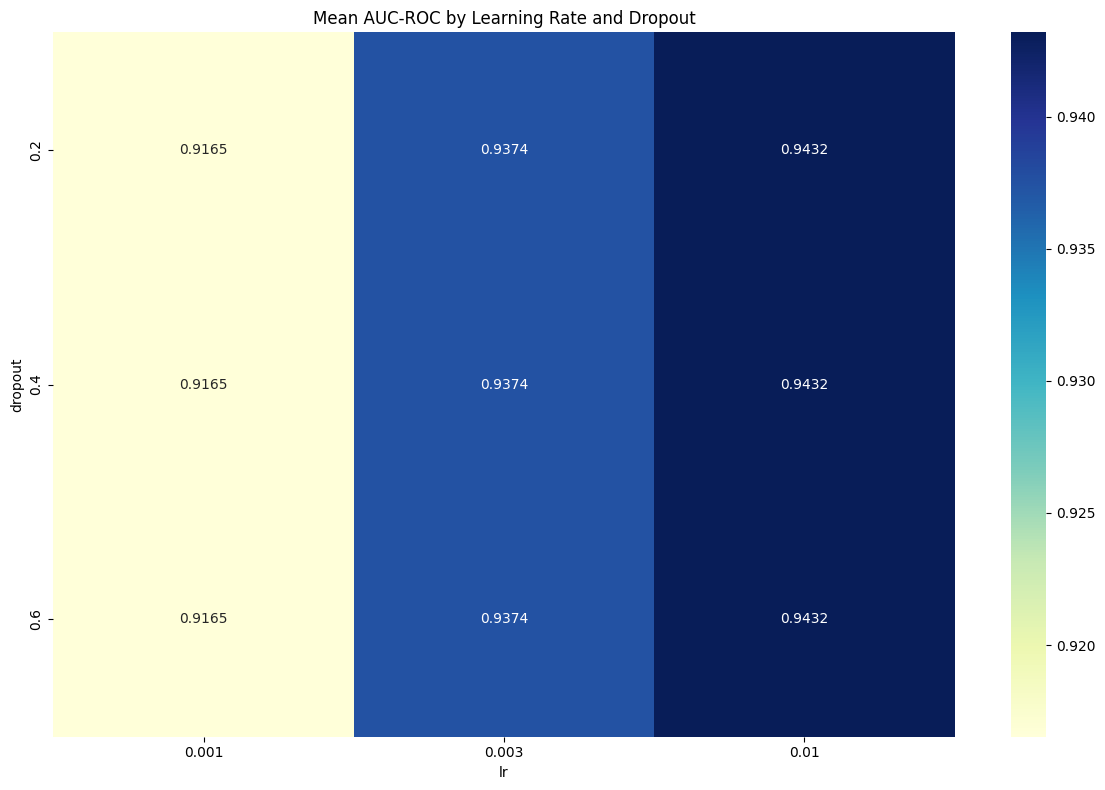


Step 2: Training final model with best hyperparameters...
Starting training with parameters:
Learning rate: 0.01, Lambda: 0.5, Dropout: 0.2, Hidden dim: 64
Epoch 1/100: Loss: 1.8952 | Train AUC: 0.8423 | Val AUC: 0.8325
Epoch 1: New best validation AUC: 0.8325
Epoch 2: New best validation AUC: 0.8988
Epoch 3: New best validation AUC: 0.9127
Epoch 4: New best validation AUC: 0.9174
Epoch 5: New best validation AUC: 0.9209
Epoch 6: New best validation AUC: 0.9235
Epoch 7: New best validation AUC: 0.9263
Epoch 8: New best validation AUC: 0.9273
Epoch 9: New best validation AUC: 0.9299
Epoch 10: New best validation AUC: 0.9312
Epoch 11/100: Loss: 0.6760 | Train AUC: 0.9431 | Val AUC: 0.9329
Epoch 11: New best validation AUC: 0.9329
Epoch 12: New best validation AUC: 0.9349
Epoch 13: New best validation AUC: 0.9360
Epoch 14: New best validation AUC: 0.9375
Epoch 16: New best validation AUC: 0.9384
Epoch 18: New best validation AUC: 0.9402
Epoch 20: New best validation AUC: 0.9413
Epoch 21/

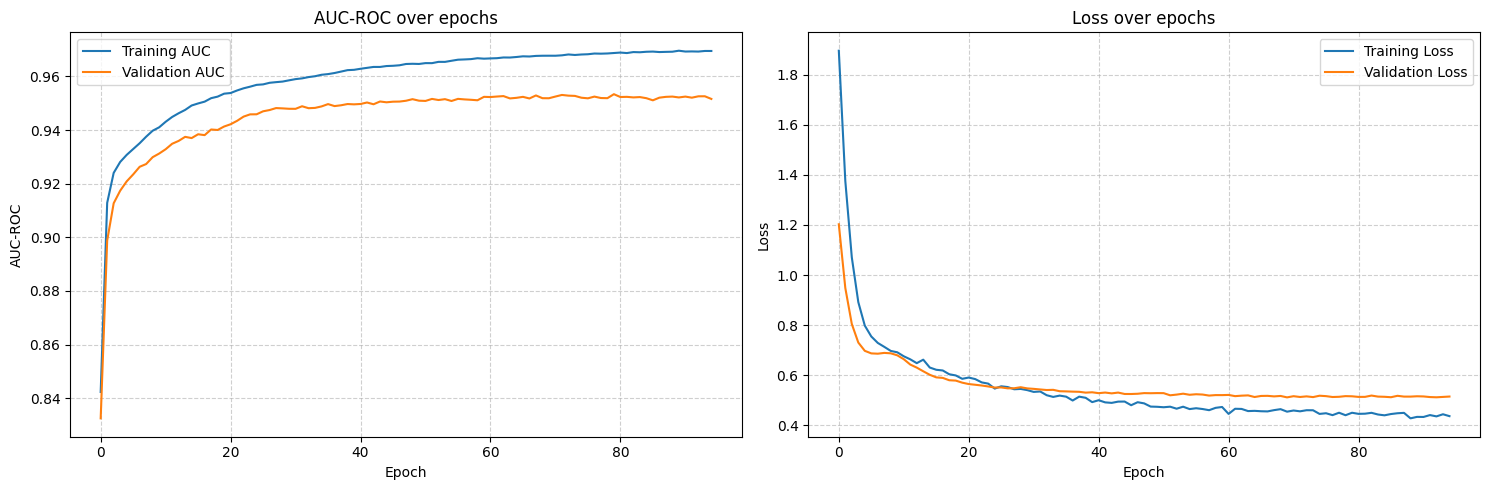

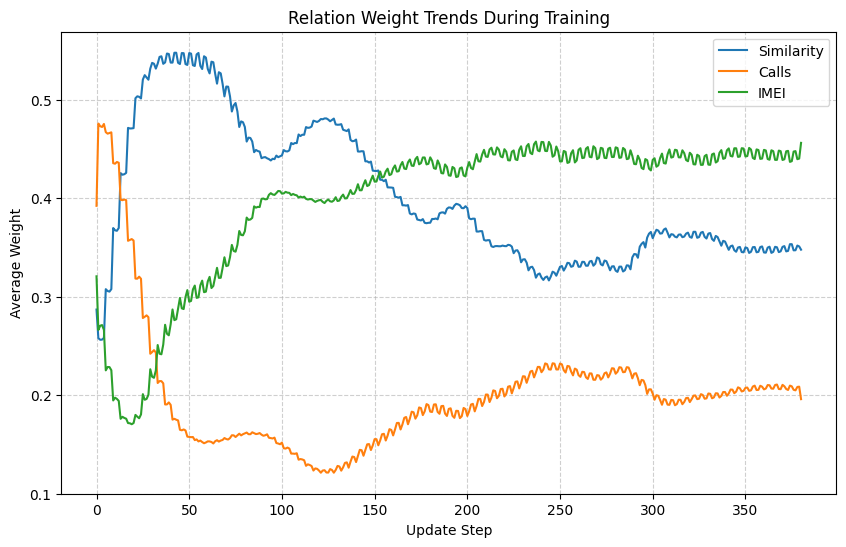


Relation Weight Analysis:
Similarity: 0.3480 ± 0.2755
Calls: 0.2057 ± 0.2004
IMEI: 0.4463 ± 0.3745


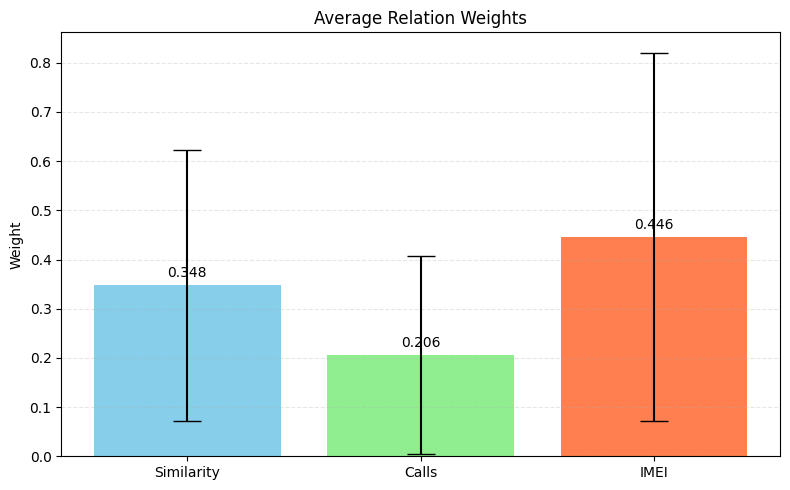


Fine-tuning complete! Best AUC-ROC: 0.9534


In [16]:
# Grid search
model, history, test_preds = run_fine_tuning()

Loading data...

Training final model with best parameters...
Starting training with parameters:
Learning rate: 0.01, Lambda: 0.5, Dropout: 0.2, Hidden dim: 64
Epoch 1/100: Loss: 1.9733 | Train AUC: 0.7797 | Val AUC: 0.8091
Epoch 1: New best validation AUC: 0.8091
Epoch 2: New best validation AUC: 0.9034
Epoch 3: New best validation AUC: 0.9120
Epoch 4: New best validation AUC: 0.9165
Epoch 5: New best validation AUC: 0.9192
Epoch 6: New best validation AUC: 0.9230
Epoch 7: New best validation AUC: 0.9271
Epoch 8: New best validation AUC: 0.9299
Epoch 9: New best validation AUC: 0.9319
Epoch 10: New best validation AUC: 0.9343
Epoch 11/100: Loss: 0.6574 | Train AUC: 0.9430 | Val AUC: 0.9363
Epoch 11: New best validation AUC: 0.9363
Epoch 12: New best validation AUC: 0.9374
Epoch 13: New best validation AUC: 0.9396
Epoch 14: New best validation AUC: 0.9408
Epoch 15: New best validation AUC: 0.9422
Epoch 16: New best validation AUC: 0.9429
Epoch 17: New best validation AUC: 0.9443
Epoch 

<Figure size 800x600 with 0 Axes>

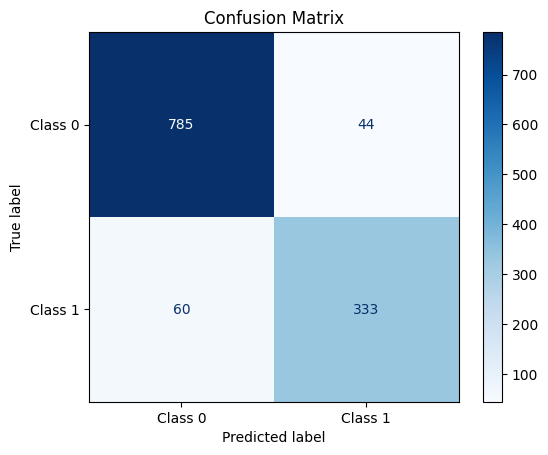

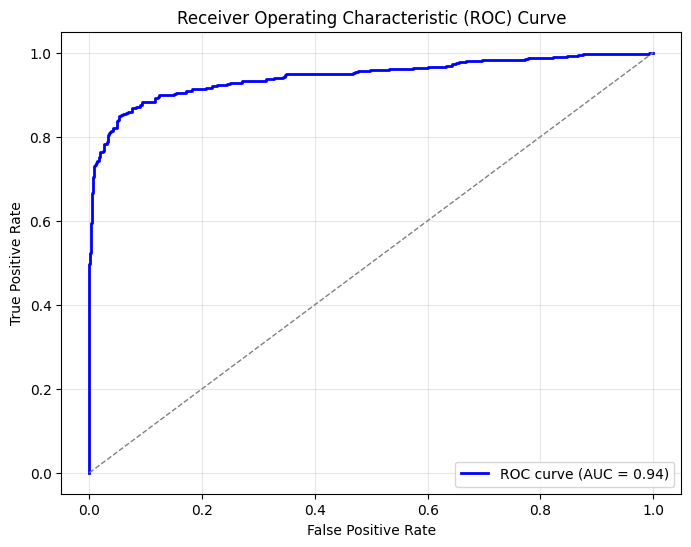

AUC-ROC Score: 0.9438

Evaluation complete!


In [44]:
model, history, results_df = run_final_evaluation_only()

#### Explainability

Which relation does the model pay more attention to in the final stage, right before making prediction?

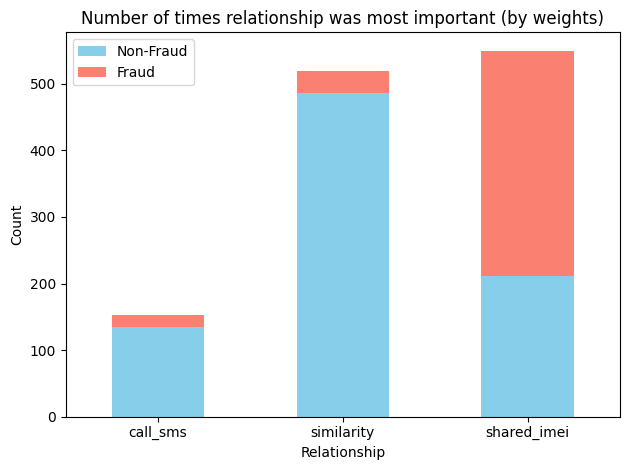

In [87]:
last_weights = pd.DataFrame(relation_weights_global[-1], columns=["similarity","call_sms", "shared_imei"])
last_weights['max_col'] = last_weights.idxmax(axis=1) # picking out the relationship that has highest weight
last_weights['predicted_class'] = preds

# count how many times the different relationships were most important
sim_as_top_cnt = sum(last_weights['max_col']=='similarity')
call_sms_as_top_cnt = sum(last_weights['max_col']=='call_sms')
imei_as_top_cnt = sum(last_weights['max_col']=='shared_imei')

group_counts = last_weights.groupby(['max_col', 'predicted_class']).size().unstack(fill_value=0)
group_counts = group_counts.loc[['call_sms', 'similarity', 'shared_imei']] # order feature columns in particular arrangement
group_counts.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])

plt.title("Number of times relationship was most important (by weights)")
plt.ylabel("Count")
plt.xlabel("Relationship")
plt.xticks(rotation=0)
plt.legend(["Non-Fraud", "Fraud"])
plt.tight_layout()
plt.show()

In [88]:
model

CARE(
  (inter): InterAgg(
    (intra_agg1): IntraAgg()
    (intra_agg2): IntraAgg()
    (intra_agg3): IntraAgg()
    (rl_module): Sequential(
      (0): Linear(in_features=104, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=3, bias=True)
    )
    (fc1): Linear(in_features=52, out_features=64, bias=True)
    (fc2): Linear(in_features=64, out_features=2, bias=True)
  )
  (xent): CrossEntropyLoss()
)

In [ ]:
def explain_node_ig(model, node_idx, features, target_class=1, baseline_type='zero'):
    """
    Computes Integrated Gradients for a single node using CARE-GNN.

    Parameters:
    - model: your CARE model
    - node_idx: int, index of node to explain
    - features: torch.Tensor, node feature matrix
    - target_class: int, class index to explain (e.g., 0 or 1)
    - baseline_type: 'zero' or 'mean' for baseline strategy

    Returns:
    - attributions: torch.Tensor of shape (num_features,)
    """
    model.eval()

    if node_idx >= features.shape[0]:
        raise IndexError(f"Node index {node_idx} is out of bounds for feature matrix with shape {features.shape}")

    # Get input feature of the node
    input_feat = features[node_idx].unsqueeze(0).requires_grad_(True)

    # Set up baseline
    #if baseline_type == 'zero':
    baseline = torch.zeros_like(input_feat)

    # reference to the shared feature tensor
    shared_features = model.inter.features

    # Define a custom forward function for Captum
    def model_forward(x):
        
        # Backup & replace
        original_feat = shared_features[node_idx].clone().detach()

        scores = []
        # Replace the node feature for each row in the batch
        # Assume x.shape = (N, 65)
        for i in range(x.shape[0]):
            shared_features[node_idx] = x[i]

            # You must collect scores for each input, forward pass
            score, _ = model([node_idx])

            scores.append(score)

        # Restore
        shared_features.data[node_idx] = original_feat

        return torch.cat(scores,dim=0)

    ig = IntegratedGradients(model_forward)
    attributions = ig.attribute(input_feat, target=target_class, baselines=baseline)
    return attributions.detach()


In [93]:
adj_lists, features, labels, train_idx, val_idx, test_idx = load_data()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
features, labels = features.to(device), labels.to(device)
train_idx, val_idx, test_idx = torch.tensor(train_idx, device=device, dtype=torch.int64), torch.tensor(val_idx, device=device, dtype=torch.int64), torch.tensor(test_idx, device=device, dtype=torch.int64)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels.cpu().numpy()),
    y=labels.cpu().numpy()
)
class_weights = torch.tensor(class_weights, dtype=torch.float, device=device)

intra1 = IntraAgg(features, features.shape[1])
intra2 = IntraAgg(features, features.shape[1])
intra3 = IntraAgg(features, features.shape[1])
inter = InterAgg(features, adj_lists, [intra1, intra2, intra3])

model = CARE(2, inter, lambda_1=0.5, class_weights=class_weights).to(device)

In [94]:
test_idx

tensor([2727, 3198, 1322,  ...,  156, 5622,  163])

In [95]:
node_id = test_idx[0].item() # a particular node in test idx
attributions = explain_node_ig(model, node_id, features, target_class=1)
print("Feature importances:", attributions)


Feature importances: tensor([[-0.0287,  0.0003,  0.0174, -0.0079,  0.0231, -0.0161, -0.0587, -0.0129,
         -0.0011,  0.0024, -0.0020,  0.0514,  0.0219, -0.0370, -0.0272,  0.1204,
          0.0257, -0.0408, -0.0109, -0.0007,  0.0310,  0.0082, -0.0558, -0.0193,
          0.0033,  0.0710]])


In [97]:
# get node_feature_names
dftemp = dataset.copy()

# Extract labels and features
labelstemp = dftemp[['phone_no_m', 'label']]
featurestemp = dftemp.drop(columns=['label'])

# Identify numerical and categorical features
numerical_featurestemp = featurestemp.columns.difference(['phone_no_m', 'imei_list', 'voc_dayname_mode', 'sms_dayname_mode'])

# Standardize numerical features
standard_scalertemp = StandardScaler()
featurestemp[numerical_featurestemp] = standard_scalertemp.fit_transform(featurestemp[numerical_featurestemp].fillna(featurestemp[numerical_featurestemp].mean()))

# Create node features matrix
node_featurestemp = featurestemp[numerical_featurestemp].values
node_features_names = featurestemp[numerical_featurestemp].columns

variable_names = dict(zip(range(65),node_features_names))

In [98]:
# finding top features
# above attributions was how much each feature contributed to the model prediction for that node for that class =1
# positive = feature pushed prediction towards target class, positive influence, convinced model node is fraudulent
# neg = feature pushed prediction away from target class (to opposite class?)
# zero = feature had little or no influence on output
# magnitude = importance strenght, higher = more influential, regardless of sign


attributions = attributions.squeeze()  # shape (65,)
topk = torch.topk(attributions.abs(), k=10)  # Top 10 most influential features
for i in topk.indices:
    print(f"Feature {i.item()} → Attribution: {attributions[i].item():.4f}")


Feature 15 → Attribution: 0.1204
Feature 25 → Attribution: 0.0710
Feature 6 → Attribution: -0.0587
Feature 22 → Attribution: -0.0558
Feature 11 → Attribution: 0.0514
Feature 17 → Attribution: -0.0408
Feature 13 → Attribution: -0.0370
Feature 20 → Attribution: 0.0310
Feature 0 → Attribution: -0.0287
Feature 14 → Attribution: -0.0272


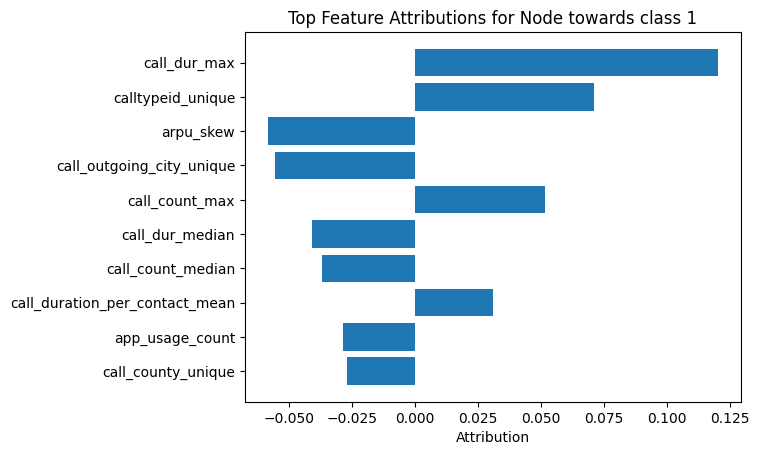

In [99]:
idxs = topk.indices.numpy()
vals = attributions[idxs].numpy()
names = [variable_names.get(i, f"f{i}") for i in idxs]

plt.barh(names, vals)
plt.xlabel("Attribution")
plt.title("Top Feature Attributions for Node towards class 1")
plt.gca().invert_yaxis()
plt.show()

In [100]:
all_attributions = []

# target class as 1 (checking attributions for predicting towards target class 1 = fraud)
for node_idx in test_idx:  # replace with your list of node IDs
    attr = explain_node_ig(model, node_idx, features, target_class=1)
    all_attributions.append(attr.squeeze(0))  # shape: (65,)

# Stack into a tensor of shape (num_nodes, num_features)
attr_matrix = torch.stack(all_attributions)  # shape: (N, F)

Feature 15 → Avg Attribution: 0.1149
Feature 11 → Avg Attribution: 0.0852
Feature 22 → Avg Attribution: 0.0836
Feature 21 → Avg Attribution: 0.0779
Feature 2 → Avg Attribution: 0.0728
Feature 17 → Avg Attribution: 0.0701
Feature 25 → Avg Attribution: 0.0635
Feature 6 → Avg Attribution: 0.0617
Feature 0 → Avg Attribution: 0.0526
Feature 19 → Avg Attribution: 0.0518


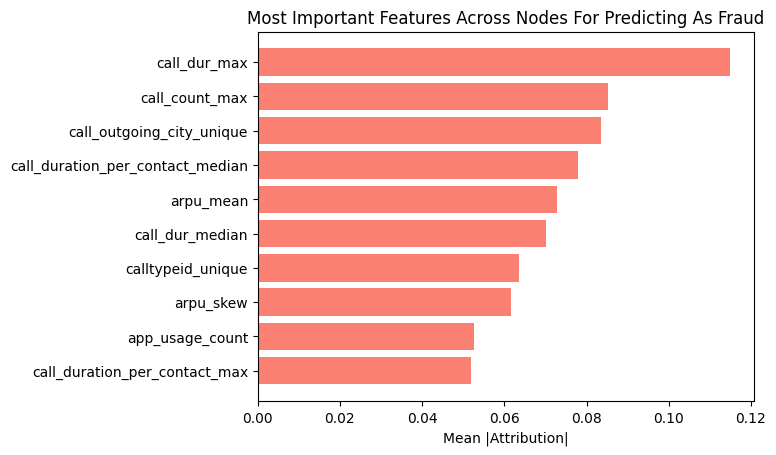

In [101]:
mean_importance = attr_matrix.abs().mean(dim=0)  # shape: (num_features,)
topk = torch.topk(mean_importance, k=10)
for i in topk.indices:
    print(f"Feature {i.item()} → Avg Attribution: {mean_importance[i].item():.4f}")

idxs = topk.indices.numpy()
vals = mean_importance[idxs].numpy()
names = [variable_names.get(i, f"f{i}") for i in idxs]

plt.barh(names, vals, color='salmon')
plt.xlabel("Mean |Attribution|")
plt.title("Most Important Features Across Nodes For Predicting As Fraud")
plt.gca().invert_yaxis()
plt.show()

Feature 3 → Avg Attribution: 0.1015
Feature 6 → Avg Attribution: 0.0946
Feature 11 → Avg Attribution: 0.0867
Feature 24 → Avg Attribution: 0.0770
Feature 15 → Avg Attribution: 0.0737
Feature 22 → Avg Attribution: 0.0730
Feature 25 → Avg Attribution: 0.0641
Feature 9 → Avg Attribution: 0.0562
Feature 4 → Avg Attribution: 0.0530
Feature 14 → Avg Attribution: 0.0456


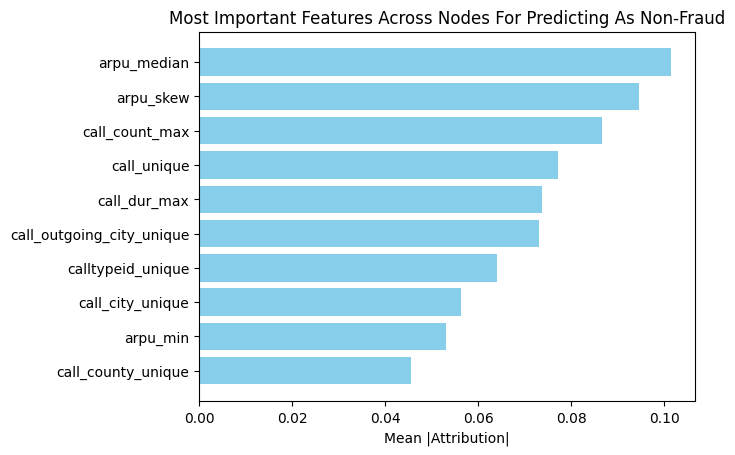

In [102]:
# across all test_idx towards being predicted as 0 non fraud
all_attributions = []

# target class as 0 (checking attributions for predicting towards target class 0 = non fraud)
for node_idx in test_idx:  # replace with your list of node IDs
    attr = explain_node_ig(model, node_idx, features, target_class=0)
    all_attributions.append(attr.squeeze(0))  # shape: (65,)

# Stack into a tensor of shape (num_nodes, num_features)
attr_matrix = torch.stack(all_attributions)  # shape: (N, F)

mean_importance = attr_matrix.abs().mean(dim=0)  # shape: (num_features,)
topk = torch.topk(mean_importance, k=10)
for i in topk.indices:
    print(f"Feature {i.item()} → Avg Attribution: {mean_importance[i].item():.4f}")

idxs = topk.indices.numpy()
vals = mean_importance[idxs].numpy()
names = [variable_names.get(i, f"f{i}") for i in idxs]

plt.barh(names, vals, color='skyblue')
plt.xlabel("Mean |Attribution|")
plt.title("Most Important Features Across Nodes For Predicting As Non-Fraud")
plt.gca().invert_yaxis()
plt.show()


Feature attributions towards class 1 for nodes that were predicted as fraud

Feature 22 → Avg Attribution: 0.1590
Feature 17 → Avg Attribution: 0.1451
Feature 15 → Avg Attribution: 0.1287
Feature 11 → Avg Attribution: 0.1071
Feature 21 → Avg Attribution: 0.0939
Feature 19 → Avg Attribution: 0.0801
Feature 0 → Avg Attribution: 0.0786
Feature 2 → Avg Attribution: 0.0772
Feature 24 → Avg Attribution: 0.0769
Feature 8 → Avg Attribution: 0.0750


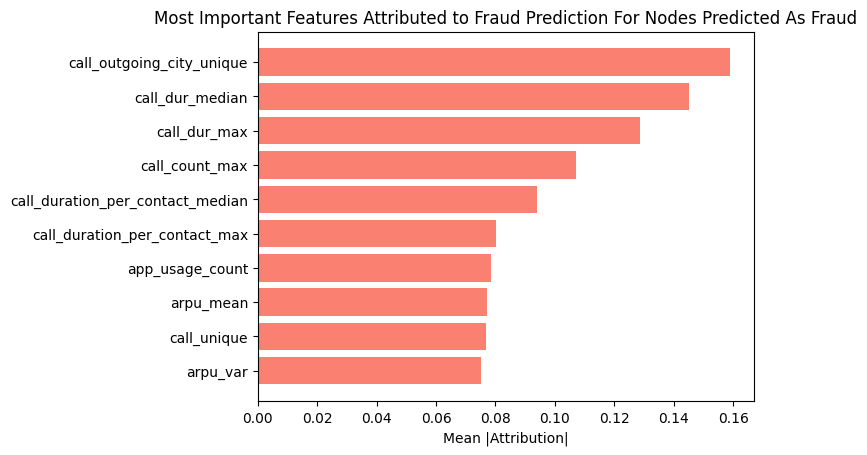

In [103]:
# for nodes predicted as fraud
fraud_nodes_idx = test_idx[preds == 1]

all_attributions_fraud = []

# target class as 1 (checking attributions for predicting towards target class 1 = fraud)
for node_idx in fraud_nodes_idx:  
    attr = explain_node_ig(model, node_idx, features, target_class=1)
    all_attributions_fraud.append(attr.squeeze(0))  # shape: (65,)

# Stack into a tensor of shape (num_nodes, num_features)
attr_matrix_fraud = torch.stack(all_attributions_fraud)  # shape: (N, F)

mean_importance_fraud = attr_matrix_fraud.abs().mean(dim=0)  # shape: (num_features,)
topk_fraud = torch.topk(mean_importance_fraud, k=10)
for i in topk_fraud.indices:
    print(f"Feature {i.item()} → Avg Attribution: {mean_importance_fraud[i].item():.4f}")

idxs = topk_fraud.indices.numpy()
vals = mean_importance_fraud[idxs].numpy()
names = [variable_names.get(i, f"f{i}") for i in idxs]

plt.barh(names, vals, color='salmon')
plt.xlabel("Mean |Attribution|")
plt.title("Most Important Features Attributed to Fraud Prediction For Nodes Predicted As Fraud")
plt.gca().invert_yaxis()
plt.show()


Feature attributions towards class 0 for nodes that were predicted as non fraud

Feature 6 → Avg Attribution: 0.0941
Feature 3 → Avg Attribution: 0.0934
Feature 11 → Avg Attribution: 0.0803
Feature 24 → Avg Attribution: 0.0588
Feature 7 → Avg Attribution: 0.0531
Feature 15 → Avg Attribution: 0.0483
Feature 25 → Avg Attribution: 0.0474
Feature 4 → Avg Attribution: 0.0453
Feature 21 → Avg Attribution: 0.0449
Feature 19 → Avg Attribution: 0.0449


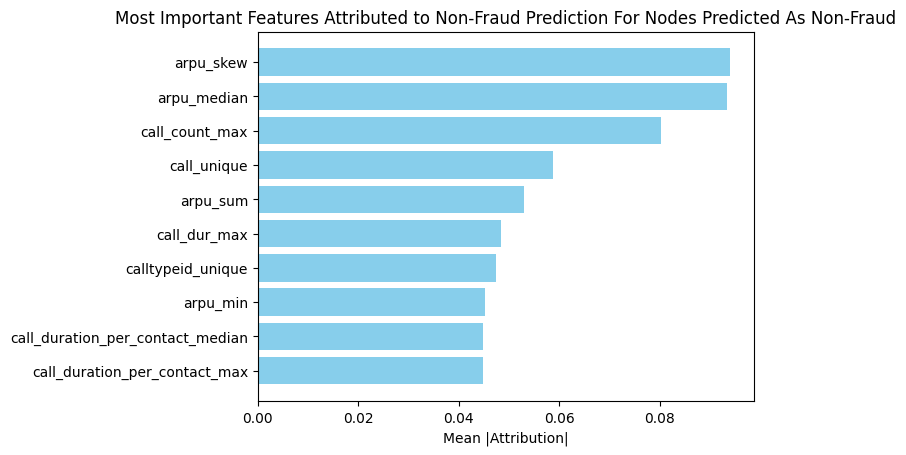

In [104]:
# for nodes predicted as non fraud
nonfraud_nodes_idx = test_idx[preds == 0]

all_attributions_nonfraud = []

# target class as 0 (checking attributions for predicting towards target class 0 = non fraud)
for node_idx in nonfraud_nodes_idx:  
    attr = explain_node_ig(model, node_idx, features, target_class=0)
    all_attributions_nonfraud.append(attr.squeeze(0))  # shape: (65,)

# Stack into a tensor of shape (num_nodes, num_features)
attr_matrix_nonfraud = torch.stack(all_attributions_nonfraud)  # shape: (N, F)

mean_importance_nonfraud = attr_matrix_nonfraud.abs().mean(dim=0)  # shape: (num_features,)
topk_nonfraud = torch.topk(mean_importance_nonfraud, k=10)
for i in topk_nonfraud.indices:
    print(f"Feature {i.item()} → Avg Attribution: {mean_importance_nonfraud[i].item():.4f}")

idxs = topk_nonfraud.indices.numpy()
vals = mean_importance_nonfraud[idxs].numpy()
names = [variable_names.get(i, f"f{i}") for i in idxs]

plt.barh(names, vals, color='skyblue')
plt.xlabel("Mean |Attribution|")
plt.title("Most Important Features Attributed to Non-Fraud Prediction For Nodes Predicted As Non-Fraud")
plt.gca().invert_yaxis()
plt.show()
